In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import statsmodels.api as sm

# =========================================================
# 0) LOAD / PREP DATA
# =========================================================

oil_price = pd.read_csv('../data/processed/Oil/oil_prices_datastream.csv')
ovx = pd.read_csv('../data/processed/Macroeconomic_variables/OVXCLS.csv')

oil_price['date'] = pd.to_datetime(oil_price['date'], errors='coerce')
ovx['date'] = pd.to_datetime(ovx['date'], errors='coerce')

df = pd.merge(oil_price, ovx, on='date', how='inner').sort_values('date').reset_index(drop=True)
df.ffill(inplace=True)

price_col = 'price' if 'price' in df.columns else df.columns[1]
df['oil_ret_1d'] = np.log(df[price_col] / df[price_col].shift(1))
df.dropna(inplace=True)

print(f"Sample: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Observations: {len(df)}")


Sample: 2007-05-11 to 2025-01-01
Observations: 4604


/var/folders/wy/gjw_3_n51t748hfngpz4zf0w0000gn/T/ipykernel_39295/3726887432.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  oil_price['date'] = pd.to_datetime(oil_price['date'], errors='coerce')


In [34]:


# =========================================================
# 1) USER CHOICES
# =========================================================
# Jump arrival:
#   lambda_t = lambda0 + exp(a + b * OVX_scaled_t)
#
# Jump size on jump days:
#   jump_size_t = -exp(c + d * OVX_scaled_t)
#
# Event definition:
#   abnormal negative move relative to rolling history
#
# Forward event:
#   at least one abnormal negative move in next horizon_days

rolling_window = 252           # past days used to define "abnormal"
future_horizon_days = 22      # roughly 1 month of trading days
use_quantile_rule = True      # if False, use z-score rule

# Quantile rule
lower_quantile = 0.01         # jump day if return < rolling 5% quantile

# Z-score rule
z_k = 2.5                     # jump day if return < rolling_mean - z_k * rolling_std

# OVX signal smoothing
use_ovx_rolling_avg = False
ovx_window = 5                # only used if use_ovx_rolling_avg = True

# Numerical stability
eps = 1e-10



In [35]:

# =========================================================
# 2) DEFINE ROLLING NEGATIVE JUMP DAYS
# =========================================================
# Use only past information to define thresholds.

if use_quantile_rule:
    df['jump_threshold'] = (
        df['oil_ret_1d']
        .rolling(rolling_window, min_periods=rolling_window)
        .quantile(lower_quantile)
        .shift(1)
    )
    jump_rule_name = f'rolling {int(lower_quantile * 100)}% quantile'
else:
    df['ret_roll_mean'] = (
        df['oil_ret_1d']
        .rolling(rolling_window, min_periods=rolling_window)
        .mean()
        .shift(1)
    )
    df['ret_roll_std'] = (
        df['oil_ret_1d']
        .rolling(rolling_window, min_periods=rolling_window)
        .std()
        .shift(1)
    )
    df['jump_threshold'] = df['ret_roll_mean'] - z_k * df['ret_roll_std']
    jump_rule_name = f'rolling mean - {z_k} std'

df['is_neg_jump'] = (df['oil_ret_1d'] < df['jump_threshold']).astype(float)
df.loc[df['jump_threshold'].isna(), 'is_neg_jump'] = np.nan



In [36]:

# =========================================================
# 3) BUILD FORWARD EVENT FOR JUMP ARRIVAL MODEL
# =========================================================
# Y_t = 1 if at least one negative abnormal move occurs in t+1,...,t+h

future_jump_cols = [df['is_neg_jump'].shift(-i) for i in range(1, future_horizon_days + 1)]
df['jump_next_h'] = pd.concat(future_jump_cols, axis=1).max(axis=1)

# OVX signal at time t
if use_ovx_rolling_avg:
    df['OVX_signal'] = df['OVXCLS'].rolling(ovx_window, min_periods=ovx_window).mean()
else:
    df['OVX_signal'] = df['OVXCLS']

# Keep modeling sample
df_arrival = df.dropna(subset=['jump_next_h', 'OVX_signal']).copy()
df_arrival['jump_next_h'] = df_arrival['jump_next_h'].astype(int)

# Scale OVX for numerical stability
x_arr = df_arrival['OVX_signal'].values.astype(float)
x_mean = x_arr.mean()
x_std = x_arr.std()

def scale_ovx(x, x_mean=x_mean, x_std=x_std):
    return (np.asarray(x, dtype=float) - x_mean) / x_std

x_arr_scaled = scale_ovx(x_arr)
y_arr = df_arrival['jump_next_h'].values.astype(float)



In [37]:

# =========================================================
# 4) FIT JUMP ARRIVAL MODEL
# =========================================================
# lambda_t = lambda0 + exp(a + b * OVX_scaled_t)
# p_t(h)   = 1 - exp(-h * lambda_t)

def unpack_arrival_params(theta):
    # theta = [log_lambda0, a, b]
    log_lambda0, a, b = theta
    lambda0 = np.exp(log_lambda0)
    return lambda0, a, b

def lambda_daily_from_theta(theta, x_scaled):
    lambda0, a, b = unpack_arrival_params(theta)
    return lambda0 + np.exp(a + b * x_scaled)

def jump_prob_h_from_theta(theta, x_scaled, horizon_days):
    lam = lambda_daily_from_theta(theta, x_scaled)
    p = 1 - np.exp(-horizon_days * lam)
    return np.clip(p, eps, 1 - eps)

def neg_loglik_arrival(theta, x_scaled, y, horizon_days):
    p = jump_prob_h_from_theta(theta, x_scaled, horizon_days)
    ll = y * np.log(p) + (1 - y) * np.log(1 - p)
    return -np.sum(ll)

theta0_arrival = np.array([
    np.log(0.002),   # baseline daily lambda0
    np.log(0.005),   # excess-intensity intercept
    0.5              # OVX slope
])

res_arrival = minimize(
    neg_loglik_arrival,
    theta0_arrival,
    args=(x_arr_scaled, y_arr, future_horizon_days),
    method='L-BFGS-B'
)

if not res_arrival.success:
    raise RuntimeError(f"Arrival model optimization failed: {res_arrival.message}")

theta_hat_arrival = res_arrival.x
lambda0_hat, a_hat, b_hat = unpack_arrival_params(theta_hat_arrival)

df_arrival['lambda_daily'] = lambda_daily_from_theta(theta_hat_arrival, x_arr_scaled)
df_arrival[f'p_jump_next_{future_horizon_days}d'] = jump_prob_h_from_theta(
    theta_hat_arrival, x_arr_scaled, future_horizon_days
)



In [38]:

# =========================================================
# 5) FIT JUMP SIZE MODEL
# =========================================================
# On jump days only:
#   jump_size_t = -exp(c + d * OVX_scaled_t)
#
# Since user requested no extra eta/noise term in the jump-size formula,
# estimate c and d from:
#   log(-r_t) = c + d * OVX_scaled_t + residual
#
# The fitted jump-size mapping is deterministic:
#   z_t_hat = -exp(c + d * OVX_scaled_t)

df_size = df.dropna(subset=['is_neg_jump', 'OVX_signal']).copy()
df_size = df_size[df_size['is_neg_jump'] == 1].copy()

# Keep only truly negative returns for log(-r)
df_size = df_size[df_size['oil_ret_1d'] < 0].copy()

if len(df_size) == 0:
    raise RuntimeError("No negative jump days found. Adjust the rolling rule or window.")

df_size['OVX_scaled'] = scale_ovx(df_size['OVX_signal'].values)
df_size['log_jump_mag'] = np.log(-df_size['oil_ret_1d'])

X_size = sm.add_constant(df_size['OVX_scaled'])
y_size = df_size['log_jump_mag']

size_model = sm.OLS(y_size, X_size).fit()

c_hat = size_model.params['const']
d_hat = size_model.params['OVX_scaled']

df_size['jump_size_fitted'] = -np.exp(c_hat + d_hat * df_size['OVX_scaled'])




NEGATIVE JUMP DEFINITION
Rule: rolling 1% quantile
Rolling window: 252 trading days
Forecast horizon: 22 trading days
Jump-day share in sample: 0.0163

ARRIVAL MODEL
Specification:
  lambda_t = lambda0 + exp(a + b * OVX_scaled_t)
  p_t(h)   = 1 - exp(-h * lambda_t)

lambda0_hat (baseline daily intensity): 0.000000
a_hat      (excess-intensity intercept): -4.391163
b_hat      (OVX slope in intensity):     0.155942
Optimization success:                    True
Final negative log-likelihood:           2390.952660
Implied baseline probability of >=1 jump in next 22 days: 0.000001

SIZE MODEL
Specification:
  jump_size_t = -exp(c + d * OVX_scaled_t)

OLS fit on jump days for log(-return):
                            OLS Regression Results                            
Dep. Variable:           log_jump_mag   R-squared:                       0.628
Model:                            OLS   Adj. R-squared:                  0.623
Method:                 Least Squares   F-statistic:                 

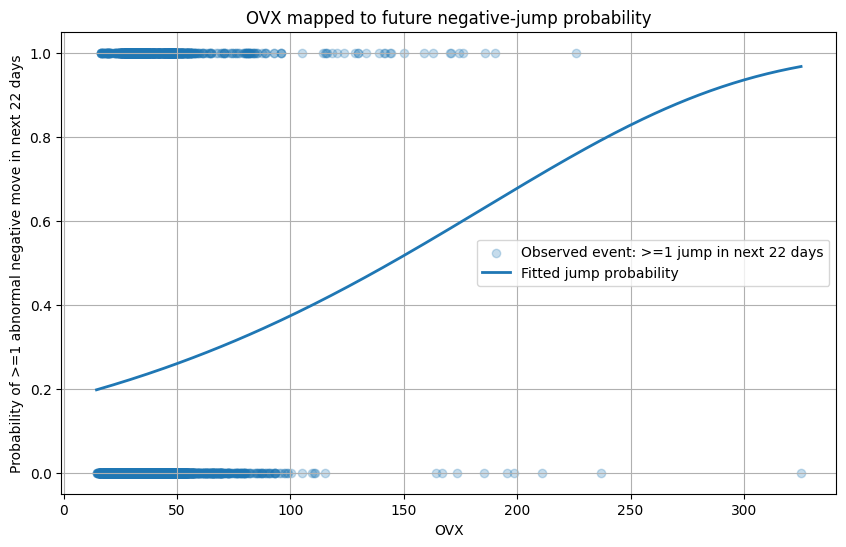

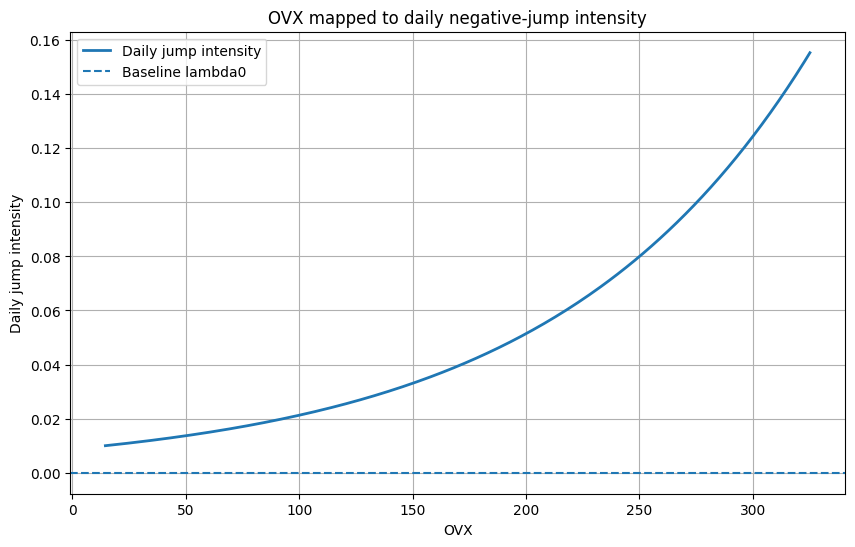

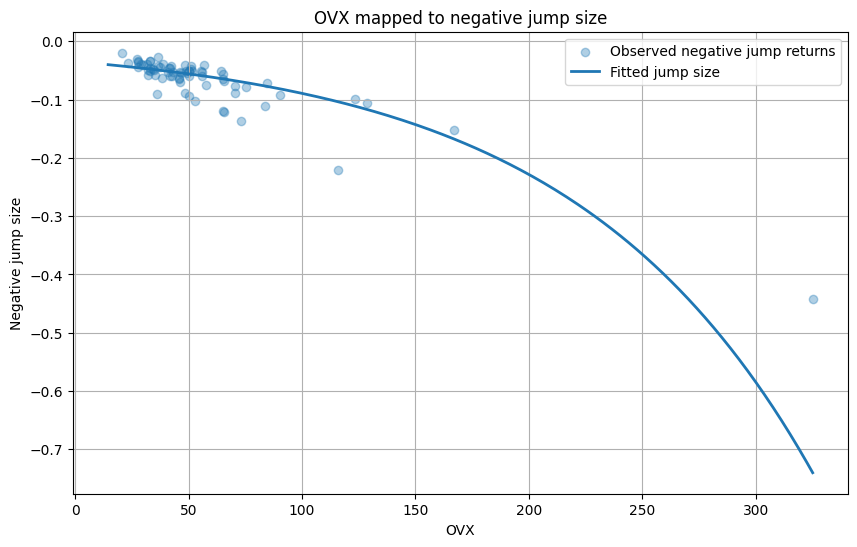

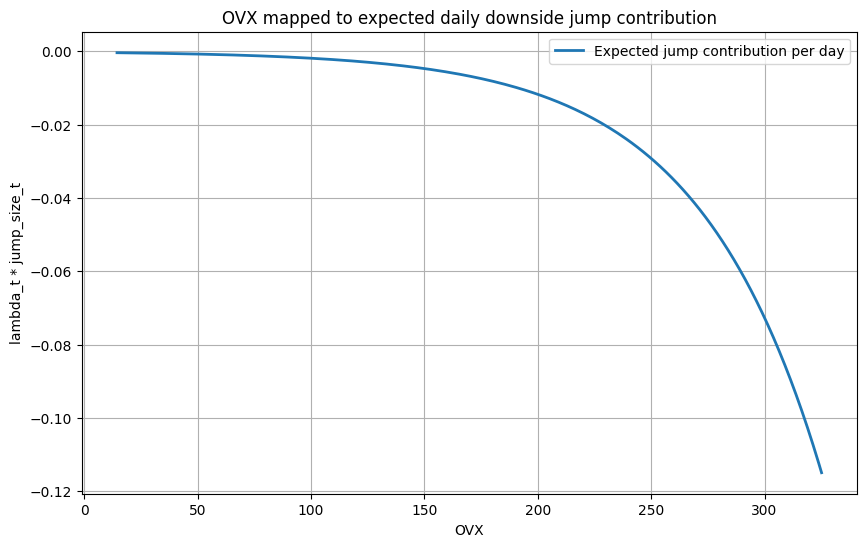

In [39]:

# =========================================================
# 6) MAPPING FUNCTIONS
# =========================================================

def ovx_to_lambda_daily(ovx):
    xs = scale_ovx(ovx)
    return lambda_daily_from_theta(theta_hat_arrival, xs)

def ovx_to_jump_prob_h(ovx, horizon_days=future_horizon_days):
    xs = scale_ovx(ovx)
    return jump_prob_h_from_theta(theta_hat_arrival, xs, horizon_days)

def ovx_to_jump_size(ovx):
    xs = scale_ovx(ovx)
    return -np.exp(c_hat + d_hat * xs)

def ovx_to_expected_jump_contribution(ovx):
    """
    Expected daily jump contribution = lambda_t * E[jump size | OVX_t]
    Under the deterministic size mapping, this is lambda_t * jump_size_t.
    """
    return ovx_to_lambda_daily(ovx) * ovx_to_jump_size(ovx)


# =========================================================
# 7) REPORT RESULTS
# =========================================================

print("\n" + "=" * 60)
print("NEGATIVE JUMP DEFINITION")
print("=" * 60)
print(f"Rule: {jump_rule_name}")
print(f"Rolling window: {rolling_window} trading days")
print(f"Forecast horizon: {future_horizon_days} trading days")
print(f"Jump-day share in sample: {df['is_neg_jump'].mean():.4f}")

print("\n" + "=" * 60)
print("ARRIVAL MODEL")
print("=" * 60)
print("Specification:")
print("  lambda_t = lambda0 + exp(a + b * OVX_scaled_t)")
print("  p_t(h)   = 1 - exp(-h * lambda_t)")
print(f"\nlambda0_hat (baseline daily intensity): {lambda0_hat:.6f}")
print(f"a_hat      (excess-intensity intercept): {a_hat:.6f}")
print(f"b_hat      (OVX slope in intensity):     {b_hat:.6f}")
print(f"Optimization success:                    {res_arrival.success}")
print(f"Final negative log-likelihood:           {res_arrival.fun:.6f}")

baseline_p_h = 1 - np.exp(-future_horizon_days * lambda0_hat)
print(f"Implied baseline probability of >=1 jump in next {future_horizon_days} days: {baseline_p_h:.6f}")

print("\n" + "=" * 60)
print("SIZE MODEL")
print("=" * 60)
print("Specification:")
print("  jump_size_t = -exp(c + d * OVX_scaled_t)")
print("\nOLS fit on jump days for log(-return):")
print(size_model.summary())

print(f"\nc_hat (baseline log jump magnitude): {c_hat:.6f}")
print(f"d_hat (OVX slope in jump size):      {d_hat:.6f}")

example_ovx = np.array([20, 30, 40, 50, 60, 70, 80, 100, 120], dtype=float)
mapping_table = pd.DataFrame({
    'OVX': example_ovx,
    'lambda_daily': ovx_to_lambda_daily(example_ovx),
    f'p_jump_next_{future_horizon_days}d': ovx_to_jump_prob_h(example_ovx),
    'jump_size': ovx_to_jump_size(example_ovx),
    'expected_jump_contribution_per_day': ovx_to_expected_jump_contribution(example_ovx)
})
print("\n" + "=" * 60)
print("OVX -> JUMP MAPPING")
print("=" * 60)
print(mapping_table.round(6))


# =========================================================
# 8) SAVE RESULTS BACK TO MAIN DF
# =========================================================

df.loc[df_arrival.index, 'OVX_signal'] = df_arrival['OVX_signal']
df.loc[df_arrival.index, 'lambda_daily_structural'] = df_arrival['lambda_daily']
df.loc[df_arrival.index, f'p_jump_next_{future_horizon_days}d_structural'] = df_arrival[f'p_jump_next_{future_horizon_days}d']

# Fitted jump size mapping for all rows where OVX exists
valid_ovx_idx = df['OVX_signal'].dropna().index if 'OVX_signal' in df.columns else df['OVXCLS'].dropna().index
if 'OVX_signal' not in df.columns:
    if use_ovx_rolling_avg:
        df['OVX_signal'] = df['OVXCLS'].rolling(ovx_window, min_periods=ovx_window).mean()
    else:
        df['OVX_signal'] = df['OVXCLS']

mask_ovx = df['OVX_signal'].notna()
df.loc[mask_ovx, 'jump_size_structural'] = ovx_to_jump_size(df.loc[mask_ovx, 'OVX_signal'].values)
df.loc[mask_ovx, 'expected_jump_contribution_per_day'] = (
    df.loc[mask_ovx, 'lambda_daily_structural'] * df.loc[mask_ovx, 'jump_size_structural']
)


# =========================================================
# 9) PLOTS
# =========================================================

ovx_grid = np.linspace(df_arrival['OVX_signal'].min(), df_arrival['OVX_signal'].max(), 250)

# Plot A: future jump probability
plt.figure(figsize=(10, 6))
plt.scatter(
    df_arrival['OVX_signal'],
    df_arrival['jump_next_h'],
    alpha=0.25,
    label=f'Observed event: >=1 jump in next {future_horizon_days} days'
)
plt.plot(
    ovx_grid,
    ovx_to_jump_prob_h(ovx_grid),
    linewidth=2,
    label='Fitted jump probability'
)
plt.xlabel('OVX')
plt.ylabel(f'Probability of >=1 abnormal negative move in next {future_horizon_days} days')
plt.title('OVX mapped to future negative-jump probability')
plt.grid(True)
plt.legend()
plt.show()

# Plot B: daily jump intensity
plt.figure(figsize=(10, 6))
plt.plot(
    ovx_grid,
    ovx_to_lambda_daily(ovx_grid),
    linewidth=2,
    label='Daily jump intensity'
)
plt.axhline(
    lambda0_hat,
    linestyle='--',
    label='Baseline lambda0'
)
plt.xlabel('OVX')
plt.ylabel('Daily jump intensity')
plt.title('OVX mapped to daily negative-jump intensity')
plt.grid(True)
plt.legend()
plt.show()

# Plot C: jump size mapping
plt.figure(figsize=(10, 6))
plt.scatter(
    df_size['OVX_signal'],
    df_size['oil_ret_1d'],
    alpha=0.35,
    label='Observed negative jump returns'
)
plt.plot(
    ovx_grid,
    ovx_to_jump_size(ovx_grid),
    linewidth=2,
    label='Fitted jump size'
)
plt.xlabel('OVX')
plt.ylabel('Negative jump size')
plt.title('OVX mapped to negative jump size')
plt.grid(True)
plt.legend()
plt.show()

# Plot D: expected jump contribution per day
plt.figure(figsize=(10, 6))
plt.plot(
    ovx_grid,
    ovx_to_expected_jump_contribution(ovx_grid),
    linewidth=2,
    label='Expected jump contribution per day'
)
plt.xlabel('OVX')
plt.ylabel('lambda_t * jump_size_t')
plt.title('OVX mapped to expected daily downside jump contribution')
plt.grid(True)
plt.legend()
plt.show()

In [14]:
oil_price = pd.read_csv('../data/processed/Oil/oil_prices_datastream.csv')
ovx = pd.read_csv('../data/processed/Macroeconomic_variables/OVXCLS.csv')

oil_price['date'] = pd.to_datetime(oil_price['date'], errors='coerce')
ovx['date'] = pd.to_datetime(ovx['date'], errors='coerce')

df = pd.merge(oil_price, ovx, on='date', how='inner').sort_values('date').reset_index(drop=True)
df.ffill(inplace=True)

price_col = 'price' if 'price' in df.columns else df.columns[1]
df['oil_ret_1d'] = np.log(df[price_col] / df[price_col].shift(1))
df.dropna(inplace=True)

print(f"Sample: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Observations: {len(df)}")

# Weekly resample
dfw = df.set_index('date').resample('W').last().copy()
dfw['oil_ret_w'] = np.log(dfw[price_col] / dfw[price_col].shift(1))
dfw['OVX_lag'] = dfw['OVXCLS'].shift(1)
dfw = dfw.dropna()


/var/folders/wy/gjw_3_n51t748hfngpz4zf0w0000gn/T/ipykernel_39295/3292798446.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  oil_price['date'] = pd.to_datetime(oil_price['date'], errors='coerce')


Sample: 2007-05-11 to 2025-01-01
Observations: 4604


In [15]:
df = dfw.copy().sort_index()

# Jump indicator: 1 if this week is a jump week
df['is_jump'] = (df['oil_ret_w'] < threshold).astype(int)

# Forward event: 1 if at least one jump occurs in weeks t+1,...,t+h
future_jump_cols = [df['is_jump'].shift(-i) for i in range(1, horizon_weeks + 1)]
df['jump_next_h'] = pd.concat(future_jump_cols, axis=1).max(axis=1)

# Predictor
if use_ovx_rolling_avg:
    df['OVX_signal'] = df['OVXCLS'].rolling(ovx_window, min_periods=ovx_window).mean()
else:
    df['OVX_signal'] = df['OVXCLS']

df_model = df.dropna(subset=['jump_next_h', 'OVX_signal']).copy()
df_model['jump_next_h'] = df_model['jump_next_h'].astype(int)

x = df_model['OVX_signal'].values.astype(float)
y = df_model['jump_next_h'].values.astype(float)

# Optional: center OVX for numerical stability
x_mean = x.mean()
x_std = x.std()
x_scaled = (x - x_mean) / x_std

In [16]:
# =========================================================
# 3) MODEL SPECIFICATION
# =========================================================
# lambda(x) = lambda0 + exp(a + b*x_scaled)
# p(x)      = 1 - exp(-h * lambda(x))
#
# We estimate (lambda0, a, b) by MLE on the binary future jump event.

def unpack_params(theta):
    """
    theta = [eta0, a, b]
    lambda0 = exp(eta0) > 0
    """
    eta0, a, b = theta
    lambda0 = np.exp(eta0)
    return lambda0, a, b

def lambda_weekly_from_theta(theta, x_scaled):
    lambda0, a, b = unpack_params(theta)
    return lambda0 + np.exp(a + b * x_scaled)

def jump_prob_from_theta(theta, x_scaled, horizon_weeks):
    lam = lambda_weekly_from_theta(theta, x_scaled)
    p = 1 - np.exp(-horizon_weeks * lam)
    return np.clip(p, eps, 1 - eps)

def neg_log_likelihood(theta, x_scaled, y, horizon_weeks):
    p = jump_prob_from_theta(theta, x_scaled, horizon_weeks)
    ll = y * np.log(p) + (1 - y) * np.log(1 - p)
    return -np.sum(ll)

In [17]:
# =========================================================
# 4) FIT THE MODEL
# =========================================================
# Starting values:
# lambda0 initial around small positive weekly intensity
# a, b set to modest values

theta0 = np.array([
    np.log(0.005),   # eta0 => lambda0 ~ 0.005 baseline weekly intensity
    np.log(0.01),    # a
    0.5              # b
])

result = minimize(
    neg_log_likelihood,
    theta0,
    args=(x_scaled, y, horizon_weeks),
    method='L-BFGS-B'
)

if not result.success:
    raise RuntimeError(f"Optimization failed: {result.message}")

theta_hat = result.x
lambda0_hat, a_hat, b_hat = unpack_params(theta_hat)

# Fitted values
df_model['lambda_weekly'] = lambda_weekly_from_theta(theta_hat, x_scaled)
df_model['p_jump_h'] = jump_prob_from_theta(theta_hat, x_scaled, horizon_weeks)


In [18]:
# =========================================================
# 5) MAPPING FUNCTIONS
# =========================================================

def scale_ovx(ovx, x_mean=x_mean, x_std=x_std):
    ovx = np.asarray(ovx, dtype=float)
    return (ovx - x_mean) / x_std

def ovx_to_lambda_weekly(ovx, theta=theta_hat):
    xs = scale_ovx(ovx)
    return lambda_weekly_from_theta(theta, xs)

def ovx_to_jump_prob_h(ovx, horizon_weeks=horizon_weeks, theta=theta_hat):
    xs = scale_ovx(ovx)
    return jump_prob_from_theta(theta, xs, horizon_weeks)

In [19]:
# =========================================================
# 6) REPORT PARAMETERS
# =========================================================

print("Estimated structural jump-intensity mapping")
print("==========================================")
print(f"lambda_0 (baseline weekly intensity): {lambda0_hat:.6f}")
print(f"a (excess-intensity intercept):        {a_hat:.6f}")
print(f"b (OVX slope on excess intensity):     {b_hat:.6f}")
print(f"Optimization success:                  {result.success}")
print(f"Final negative log-likelihood:         {result.fun:.6f}")

baseline_p_h = 1 - np.exp(-horizon_weeks * lambda0_hat)
print(f"\nImplied baseline {horizon_weeks}-week jump probability from lambda_0 alone: {baseline_p_h:.6f}")

# Example mapping table
ovx_grid_example = np.array([20, 30, 40, 50, 60, 70, 80, 100, 120], dtype=float)
mapping_table = pd.DataFrame({
    'OVX': ovx_grid_example,
    'lambda_weekly': ovx_to_lambda_weekly(ovx_grid_example),
    f'p_jump_{horizon_weeks}w': ovx_to_jump_prob_h(ovx_grid_example)
})
print("\nOVX -> structural jump mapping")
print(mapping_table.round(6))


Estimated structural jump-intensity mapping
lambda_0 (baseline weekly intensity): 0.000000
a (excess-intensity intercept):        -3.835765
b (OVX slope on excess intensity):     0.815329
Optimization success:                  True
Final negative log-likelihood:         278.163072

Implied baseline 4-week jump probability from lambda_0 alone: 0.000000

OVX -> structural jump mapping
     OVX  lambda_weekly  p_jump_4w
0   20.0       0.008726   0.034303
1   30.0       0.014408   0.056002
2   40.0       0.023788   0.090765
3   50.0       0.039275   0.145381
4   60.0       0.064845   0.228469
5   70.0       0.107061   0.348349
6   80.0       0.176764   0.506905
7  100.0       0.481850   0.854474
8  120.0       1.313501   0.994773


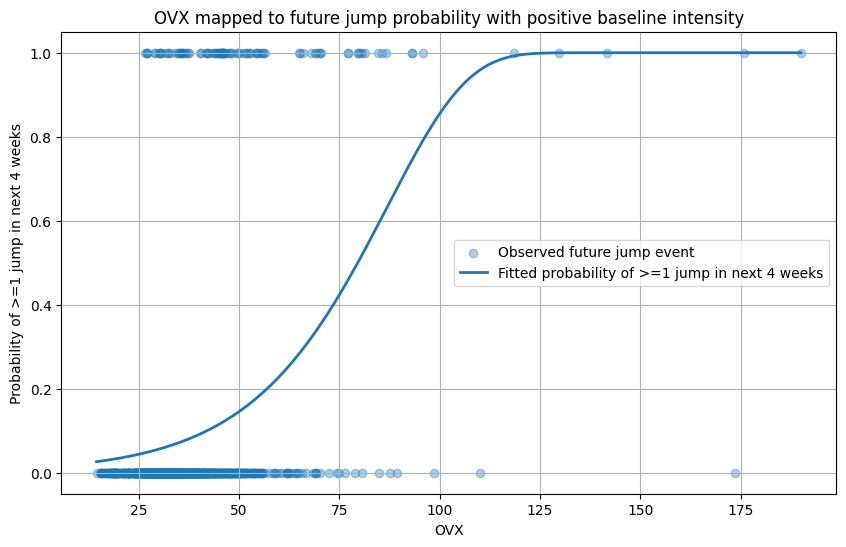

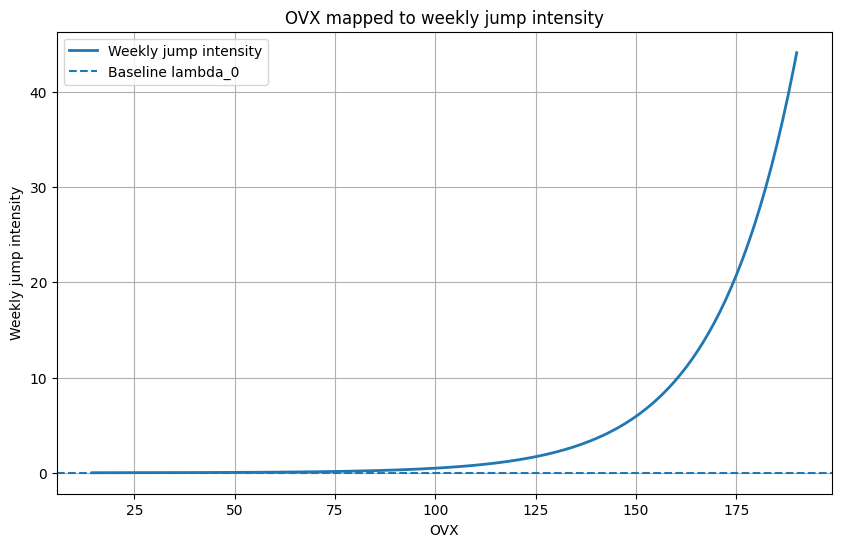

In [20]:
# =========================================================
# 7) PLOT
# =========================================================

ovx_grid = np.linspace(df_model['OVX_signal'].min(), df_model['OVX_signal'].max(), 250)
p_grid = ovx_to_jump_prob_h(ovx_grid)
lambda_grid = ovx_to_lambda_weekly(ovx_grid)

plt.figure(figsize=(10, 6))
plt.scatter(df_model['OVX_signal'], df_model['jump_next_h'], alpha=0.35, label='Observed future jump event')
plt.plot(ovx_grid, p_grid, linewidth=2, label=f'Fitted probability of >=1 jump in next {horizon_weeks} weeks')
plt.xlabel('OVX')
plt.ylabel(f'Probability of >=1 jump in next {horizon_weeks} weeks')
plt.title('OVX mapped to future jump probability with positive baseline intensity')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(ovx_grid, lambda_grid, linewidth=2, label='Weekly jump intensity')
plt.axhline(lambda0_hat, linestyle='--', label='Baseline lambda_0')
plt.xlabel('OVX')
plt.ylabel('Weekly jump intensity')
plt.title('OVX mapped to weekly jump intensity')
plt.legend()
plt.grid(True)
plt.show()